# Project : Customer Churn Prediction
### Dataset : Telco Customer Churn Dataset (Kaggle)


## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

print("All libraries imported successfully!")

## 2. Load Telco Customer Churn Dataset

In [ ]:
df_raw = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

SAMPLE_SIZE = 500

if SAMPLE_SIZE and len(df_raw) > SAMPLE_SIZE:
    df_raw = df_raw.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print("\nDataset shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
df_raw.head(50)

## 3. Preprocessing (Missing Values, Encoding & Feature Engineering)

In [ ]:
df = df_raw.copy()

if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Null values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print("\nNull values after cleaning:", df.isnull().sum().sum())

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
existing_service_cols = [c for c in service_cols if c in df.columns]
if existing_service_cols:
    df['num_services'] = (df[existing_service_cols] == 'Yes').sum(axis=1)

rename_map = {
    'SeniorCitizen'  : 'senior_citizen',
    'tenure'         : 'tenure',
    'MonthlyCharges' : 'monthly_charges',
    'TotalCharges'   : 'total_charges',
    'Contract'       : 'contract',
    'InternetService': 'internet',
    'gender'         : 'gender',
    'Churn'          : 'churn',
    'num_services'   : 'num_services'
}
keep_cols = [c for c in rename_map if c in df.columns]
df = df[keep_cols].rename(columns=rename_map)

le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nAfter preprocessing:")
print(df.dtypes)
print("\nChurn Distribution:\n", df['churn'].value_counts())
df.describe().round(2)

## 4. Exploratory Data Analysis (EDA)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['churn'].value_counts().plot(
    kind='bar', ax=axes[0], color=['green', 'red'], edgecolor='black'
)
axes[0].set_title('Churn Distribution')
axes[0].set_xlabel('Churn (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

df[df['churn'] == 0]['monthly_charges'].hist(
    ax=axes[1], alpha=0.6, color='green', label='No Churn', bins=15
)
df[df['churn'] == 1]['monthly_charges'].hist(
    ax=axes[1], alpha=0.6, color='red', label='Churn', bins=15
)
axes[1].set_title('Monthly Charges vs Churn')
axes[1].set_xlabel('Monthly Charges')
axes[1].legend()

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='Reds', ax=axes[2])
axes[2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Feature Selection & Train-Test Split

In [ ]:
X = df.drop('churn', axis=1)
y = df['churn']

sc = StandardScaler()
Xs = sc.fit_transform(X)

X_tr, X_te, y_tr, y_te = train_test_split(Xs, y, test_size=0.3, random_state=42)

print("Training samples:", X_tr.shape[0])
print("Testing  samples:", X_te.shape[0])
print("Features used   :", X.columns.tolist())

## 6. Logistic Regression (Supervised Learning)

In [ ]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_tr, y_tr)
y_lr = lr.predict(X_te)
acc_lr = accuracy_score(y_te, y_lr)

print("Logistic Regression Accuracy:", round(acc_lr, 4))
print("\nClassification Report:")
print(classification_report(y_te, y_lr))

## 7. Linear Regression (Supervised Learning)

In [ ]:
linr = LinearRegression()
linr.fit(X_tr, y_tr)
y_linr = (linr.predict(X_te)).astype(int)
acc_linr = accuracy_score(y_te, y_linr)

print("Linear Regression Accuracy:", round(acc_linr, 4))
print("\nClassification Report:")
print(classification_report(y_te, y_linr))

## 8. Decision Tree Classifier (Supervised Learning)

In [ ]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_tr, y_tr)
y_dt = dt.predict(X_te)
acc_dt = accuracy_score(y_te, y_dt)

print("Decision Tree Accuracy:", round(acc_dt, 4))
print("\nClassification Report:")
print(classification_report(y_te, y_dt))

## 9. K-Nearest Neighbors (KNN)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_tr, y_tr)
y_knn = knn.predict(X_te)
acc_knn = accuracy_score(y_te, y_knn)

print("KNN Accuracy:", round(acc_knn, 4))
print("\nClassification Report:")
print(classification_report(y_te, y_knn))

## 10. Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_tr, y_tr)
y_rf = rf.predict(X_te)
acc_rf = accuracy_score(y_te, y_rf)

print("Random Forest Accuracy:", round(acc_rf, 4))
print("\nClassification Report:")
print(classification_report(y_te, y_rf))

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
feat_imp.plot(kind='bar', color='blue', edgecolor='black')
plt.title('Random Forest — Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

## 11. Confusion Matrices (Supervised Models)

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
preds = [
    ('Logistic Reg', y_lr),
    ('Linear Reg',   y_linr),
    ('Decision Tree', y_dt),
    ('KNN',           y_knn)
]

for ax, (name, pred) in zip(axes, preds):
    cm = confusion_matrix(y_te, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Reds',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Supervised Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_part1.png', dpi=100, bbox_inches='tight')
plt.show()

## 12. MLP Neural Network (MLPClassifier)

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32, 16),
    max_iter=500,
    activation='relu',
    random_state=42
)
mlp.fit(X_tr, y_tr)
y_mlp = mlp.predict(X_te)
acc_mlp = accuracy_score(y_te, y_mlp)

print("MLP (Neural Network) Accuracy:", round(acc_mlp, 4))
print("\nClassification Report:")
print(classification_report(y_te, y_mlp))

plt.figure(figsize=(6, 3))
plt.plot(mlp.loss_curve_, color='red')
plt.title('MLP Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig('mlp_loss.png', dpi=100, bbox_inches='tight')
plt.show()

## 13. K-Fold Cross Validation

In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Reg' : LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'KNN'          : KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'MLP'          : MLPClassifier(hidden_layer_sizes=(128, 64, 32, 16), max_iter=500, random_state=42)
}

print("=" * 40)
print("    K-Fold Cross Validation Results")
print("-" * 40)
print(f"{'Model':<18} {'Mean Acc':>10} {'Std Dev':>10}")
print("=" * 40)

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, Xs, y, cv=kf, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:<18} {scores.mean():>10.4f} {scores.std():>10.4f}")

print("=" * 40)

plt.figure(figsize=(9, 4))
plt.boxplot(
    [cv_results[m] for m in cv_results],
    labels=list(cv_results.keys()),
    patch_artist=True,
    boxprops=dict(facecolor='lightcoral', color='red'),
    medianprops=dict(color='darkred', linewidth=2)
)
plt.title('K-Fold Cross Validation Accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig('kfold_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()

## 14. PCA (Dimensionality Reduction to 2D)

In [ ]:
pca_full = PCA()
pca_full.fit(Xs)
ev = pca_full.explained_variance_ratio_

pca2 = PCA(n_components=2)
Xp = pca2.fit_transform(Xs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(ev) + 1), ev * 100, color='red', edgecolor='black')
axes[0].set_title('Explained Variance per PCA Component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Variance (%)')

sc_plot = axes[1].scatter(Xp[:, 0], Xp[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.colorbar(sc_plot, ax=axes[1], label='Churn')
axes[1].set_title('PCA 2D Visualization (colored by Churn)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('pca_plot.png', dpi=100, bbox_inches='tight')
plt.show()

print("Variance explained by PC1 + PC2:", round(sum(ev[:2]) * 100, 2), "%")

## 15. K-Means Clustering (Unsupervised Learning)

In [ ]:
inertias = []
K_range = range(2, 9)
for k in K_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(Xs)
    inertias.append(km_tmp.inertia_)

km = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = km.fit_predict(Xs)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Elbow Method — Optimal K')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')

axes[1].scatter(Xp[:, 0], Xp[:, 1], c=km_labels, cmap='Set1', alpha=0.7)
axes[1].set_title('K-Means Clusters (K=2)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

axes[2].scatter(Xp[:, 0], Xp[:, 1], c=y, cmap='Set1', alpha=0.7)
axes[2].set_title('Actual Churn Labels')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('kmeans_plot.png', dpi=100, bbox_inches='tight')
plt.show()

print("K-Means cluster counts:", pd.Series(km_labels).value_counts().to_dict())

## 16. Hierarchical Clustering (Unsupervised Learning)

In [ ]:
Xs_hc = Xs[:min(500, len(Xs))]
linked = linkage(Xs_hc, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index / Cluster Size')
plt.ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=100, bbox_inches='tight')
plt.show()

hc = AgglomerativeClustering(n_clusters=2)
hc_labels = hc.fit_predict(Xs)

plt.figure(figsize=(6, 4))
plt.scatter(Xp[:, 0], Xp[:, 1], c=hc_labels, cmap='Set2', alpha=0.7)
plt.title('Hierarchical Clustering Result')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('hc_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

print("Hierarchical cluster counts:", pd.Series(hc_labels).value_counts().to_dict())

## 17. All Model Confusion Matrices

KeyboardInterrupt: 

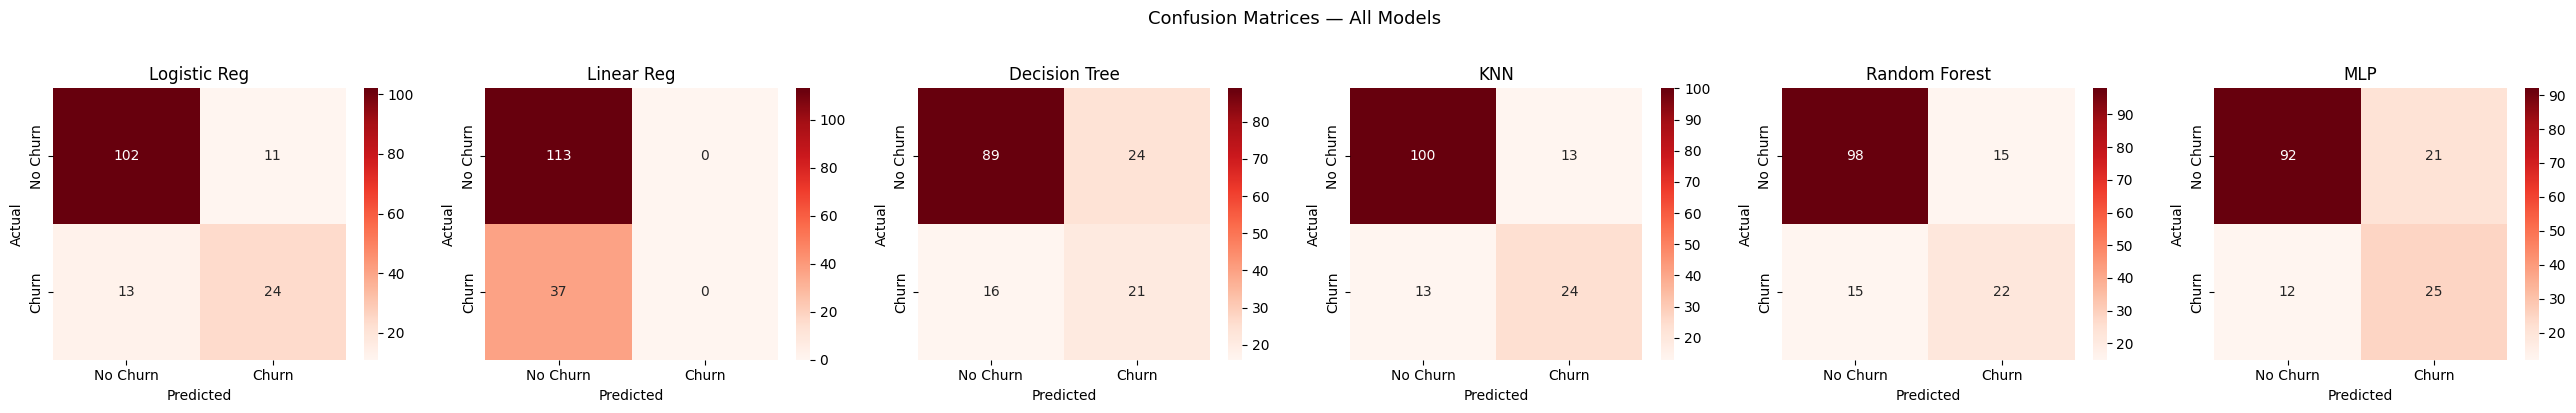

In [17]:
fig, axes = plt.subplots(1, 6, figsize=(26, 4))
preds = [
    ('Logistic Reg',  y_lr),
    ('Linear Reg',    y_linr),
    ('Decision Tree', y_dt),
    ('KNN',           y_knn),
    ('Random Forest', y_rf),
    ('MLP',           y_mlp)
]

for ax, (name, pred) in zip(axes, preds):
    cm = confusion_matrix(y_te, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Reds',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=100, bbox_inches='tight')
plt.show()

## 18. All Models Accuracy & Metrics Comparison

In [ ]:
clf_preds = {
    'Logistic Reg' : y_lr,
    'Linear Reg'   : y_linr,
    'Decision Tree': y_dt,
    'KNN'          : y_knn,
    'Random Forest': y_rf,
    'MLP'          : y_mlp,
}

rows = []
for name, pred in clf_preds.items():
    rows.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, pred),  4),
        'Precision': round(precision_score(y_te, pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_te, pred,    zero_division=0), 4),
        'F1-Score' : round(f1_score(y_te, pred,        zero_division=0), 4),
    })

metrics_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("=" * 65)
print("              Model Performance Comparison")
print("=" * 65)
print(metrics_df.to_string(index=False))
print("=" * 65)

best_name = metrics_df.iloc[0]['Model']
best_acc  = metrics_df.iloc[0]['Accuracy']
print(f"\nBest Model: {best_name}  |  Accuracy = {best_acc}")

colors = ['green' if n == best_name else 'red' for n in metrics_df['Model']]
plt.figure(figsize=(9, 4))
plt.bar(metrics_df['Model'], metrics_df['Accuracy'], color=colors, edgecolor='black')
plt.title('Model Accuracy Comparison (Green = Best)')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_df))
width = 0.18
bar_colors = ['green', 'red', 'yellow', 'blue']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (metric, color) in enumerate(zip(metric_cols, bar_colors)):
    ax.bar(x + i * width, metrics_df[metric], width, label=metric, color=color, edgecolor='black', alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_df['Model'], rotation=15)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy, Precision, Recall & F1-Score')
ax.legend()
plt.tight_layout()
plt.savefig('model_metrics_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 19. Prediction for a New Customer

**Encoding reference for manual predictions:**
- `gender` : 0 = Female, 1 = Male  
- `contract` : 0 = Month-to-month, 1 = One year, 2 = Two year  
- `internet` : 0 = DSL, 1 = Fiber optic, 2 = No  
- `senior_citizen` : 0 = No, 1 = Yes

In [ ]:
def predict_new_customer(customer_data, customer_id=1):
    """Predict churn for a new customer using all trained classifiers."""
    new_df  = pd.DataFrame([customer_data])
    new_sc  = sc.transform(new_df)

    classifiers = {
        'Logistic Regression': lr,
        'Decision Tree'      : dt,
        'KNN'                : knn,
        'Random Forest'      : rf,
        'MLP'                : mlp,
    }

    print("=" * 48)
    print(f"  Customer ({customer_id}) Churn Predictions")
    print("=" * 48)
    for name, model in classifiers.items():
        pred  = model.predict(new_sc)[0]
        label = "Churn" if pred == 1 else "No Churn"
        if hasattr(model, 'predict_proba'):
            prob = model.predict_proba(new_sc)[0][1]
            print(f"{name:<22}: {label}  (prob = {prob:.2f})")
        else:
            print(f"{name:<22}: {label}")
    print("=" * 48)

feature_names = X.columns.tolist()
print("Feature order expected:", feature_names)

### Customer 01 — High monthly charges, short tenure, month-to-month contract

In [ ]:
c1 = {col: 0 for col in feature_names}
c1.update({
    'senior_citizen'  : 0,
    'tenure'          : 5,
    'monthly_charges' : 90.0,
    'total_charges'   : 450.0,
    'contract'        : 0,   
    'internet'        : 1,    
    'gender'          : 1,    
    'num_services'    : 2,
})
predict_new_customer(c1, customer_id=1)

### Customer 02 — Low monthly charges, long tenure, two-year contract

In [ ]:
c2 = {col: 0 for col in feature_names}
c2.update({
    'senior_citizen'  : 0,
    'tenure'          : 48,
    'monthly_charges' : 25.0,
    'total_charges'   : 1200.0,
    'contract'        : 2,    
    'internet'        : 0,    
    'gender'          : 0,    
    'num_services'    : 5,
})
predict_new_customer(c2, customer_id=2)

### Customer 03 — Senior citizen, moderate charges, one-year contract

In [ ]:
c3 = {col: 0 for col in feature_names}
c3.update({
    'senior_citizen'  : 1,
    'tenure'          : 20,
    'monthly_charges' : 55.0,
    'total_charges'   : 1100.0,
    'contract'        : 1,
    'internet'        : 1,
    'gender'          : 0,
    'num_services'    : 3,
})
predict_new_customer(c3, customer_id=3)